In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df= pd.read_csv("store_customers.csv")

In [31]:
print(df.head())
print(df.info())
print(df.describe())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None
        CustomerID         Age

In [32]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [33]:
#clean null
df.dropna(inplace=True)

In [34]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [35]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


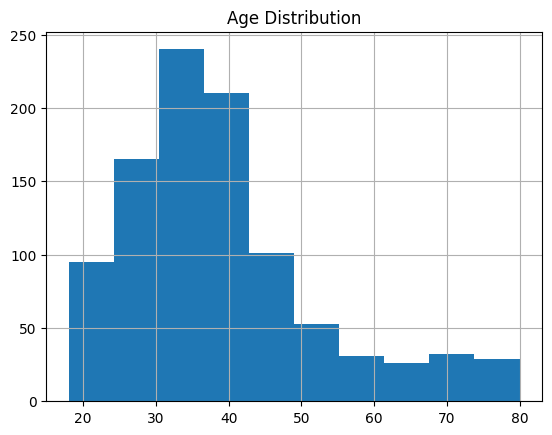

In [36]:
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

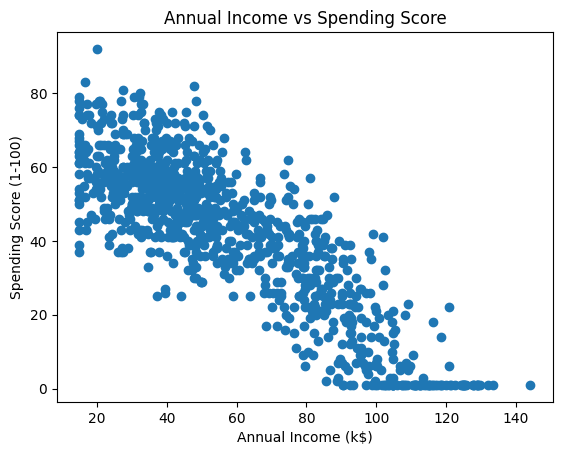

In [37]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()

In [38]:
def segment_customer(row):
  income=row['Annual Income (k$)']
  spending=row['Spending Score (1-100)']
  if income >60 and spending >60:
    return "Premium"
  elif income>60 and spending<40:
    return "Careful"
  elif income<40 and spending>60:
    return "Impulsive"
  elif income<40 and spending<40:
    return "Budget"
  else:
    return "Average"
df['Segment']=df.apply(segment_customer,axis=1)
print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
1        1001      M  34.0                48.4                    37.0   
2        1002      F  40.0                70.5                    26.0   
3        1003      F  47.0                81.1                    30.0   
4        1004      F  33.0                42.1                    58.0   

   Segment  
0  Average  
1  Average  
2  Careful  
3  Careful  
4  Average  


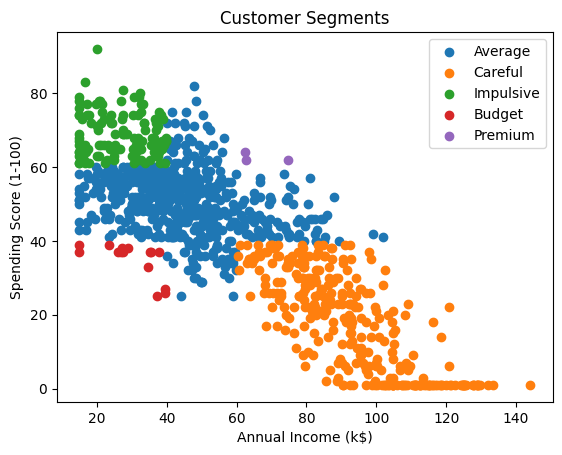

In [39]:
for segment in df['Segment'].unique():
  subset=df[df['Segment']==segment]
  plt.scatter(subset['Annual Income (k$)'],subset['Spending Score (1-100)'],label=segment)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.legend()
plt.show()

In [39]:
"""Key Insights:

Customers with high income but low spending (Careful) represent untapped revenue potential

Premium customers (high income, high spending) are the most valuable segment

Impulsive customers spend heavily despite low income, indicating behavior-driven purchases

Budget customers contribute least and are price-sensitive

Majority of customers fall into the mid-level segment, showing moderate spending behavior"""